In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

print("Path to dataset files:", path)

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 3.27k/3.27k [00:00<00:00, 2.24MB/s]

Extracting files...
Path to dataset files: C:\Users\Acer\.cache\kagglehub\datasets\rakeshrau\social-network-ads\versions\1


In [2]:
import pandas as pd
import numpy as np

In [8]:
import os

path = r"C:\Users\Acer\.cache\kagglehub\datasets\rakeshrau\social-network-ads\versions\1"
print(os.listdir(path))

['Social_Network_Ads.csv']


In [9]:
df = pd.read_csv(
    r"C:\Users\Acer\.cache\kagglehub\datasets\rakeshrau\social-network-ads\versions\1\Social_Network_Ads.csv"
)

In [11]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [12]:
df = df[['Age' , 'EstimatedSalary' , 'Purchased']]

In [14]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [15]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
x_scaled = std.fit_transform(df.iloc[: , :2])

In [17]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x_scaled , df['Purchased'] , test_size= 0.2 , random_state=42)

In [18]:
x_train.shape

(320, 2)

In [19]:
x_test.shape

(80, 2)

In [41]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential 
from keras.layers import Dense

In [42]:
model = Sequential()

model.add(Dense(10 , activation= 'relu' , input_dim= 2))
model.add(Dense(10 , activation= 'relu'))
model.add(Dense(1 , activation= 'sigmoid'))

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(loss= 'binary_crossentropy' , metrics= ['accuracy'])

history = model.fit(x_scaled , df['Purchased'] , epochs= 200 , batch_size= 1 , validation_split= 0.2) # In batch size , if i give all number of rows i.e 400 then it become batch gradient descent . If i give 1 then it will stochastic gradient descent 

Epoch 1/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9094 - loss: 0.2761 - val_accuracy: 0.9000 - val_loss: 0.2434
Epoch 2/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9125 - loss: 0.2710 - val_accuracy: 0.9125 - val_loss: 0.2126
Epoch 3/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9125 - loss: 0.2767 - val_accuracy: 0.9000 - val_loss: 0.2369
Epoch 4/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9125 - loss: 0.2716 - val_accuracy: 0.9000 - val_loss: 0.2373
Epoch 5/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9125 - loss: 0.2804 - val_accuracy: 0.9000 - val_loss: 0.2266
Epoch 6/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9094 - loss: 0.2682 - val_accuracy: 0.9000 - val_loss: 0.2664
Epoch 7/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9156 - loss: 0.2710 - val_accuracy: 0.9125 - val_loss: 0.2323
Epoch 8/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9094 - loss: 0.2745 - val_accu

Batch Gradient descent will take less time to complete epoch than SGD but SGD is more faster to converge into correct output .

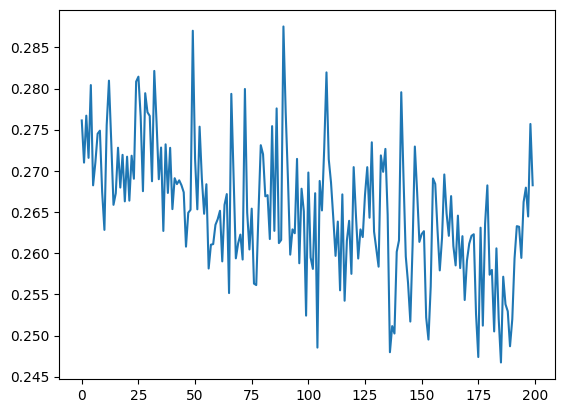

In [49]:
import matplotlib.pyplot as plt 
plt.plot(history.history['loss'])

In [50]:
history2 = model.fit(x_scaled , df['Purchased'] , epochs= 200 , batch_size= 400 , validation_split=0.2)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step - accuracy: 0.9062 - loss: 0.2536 - val_accuracy: 0.9125 - val_loss: 0.1934
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9062 - loss: 0.2529 - val_accuracy: 0.9125 - val_loss: 0.1951
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9062 - loss: 0.2522 - val_accuracy: 0.9125 - val_loss: 0.1968
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9062 - loss: 0.2515 - val_accuracy: 0.9125 - val_loss: 0.1984
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9094 - loss: 0.2508 - val_accuracy: 0.9125 - val_loss: 0.2001
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9094 - loss: 0.2500 - val_accuracy: 0.9125 - val_loss: 0.2018
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9094 - loss: 0.2493 - val_accuracy: 0.9125 - val_loss: 0.2035
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9094 - loss: 0.2485 - val_accuracy: 0.9125 - val_l

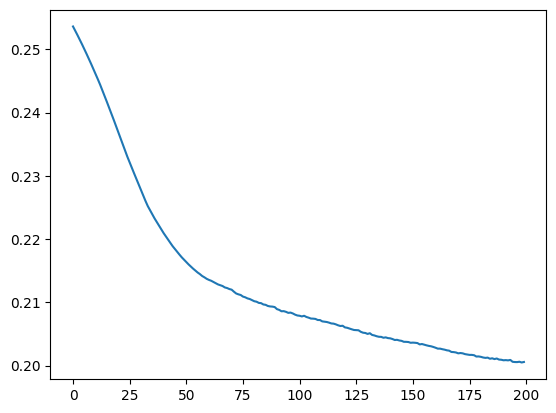

In [51]:
plt.plot(history2.history['loss'])